# Simulaciones

### Armado del avión

In [1]:
import random
import matplotlib.pyplot as plt  # lo subimos acá para no depender de las celdas de las corridas Monte Carlo

# Armamos el avión

n_filas = 25
# -2 es ventana izquierda | -1 es pasillo izquierda | 1 es pasillo derecha | 2 es ventana derecha
lados = [-2, -1, 1, 2]


# Creamos los asientos fila por fila, respetando el orden de los lados.
asientos = []

for fila in range(1, n_filas + 1):
    for lado in lados:
        asiento = (fila, lado)
        asientos.append(asiento)

print(f"Cantidad de asientos: {len(asientos)}") 
print("Primeros 6 asientos:", asientos[:6])

Cantidad de asientos: 100
Primeros 6 asientos: [(1, -2), (1, -1), (1, 1), (1, 2), (2, -2), (2, -1)]


### Políticas

In [2]:
# Politica Random

def orden_random(asientos):
    """
    Politica Random: no hay ningun orden. Cada pasajero sube en
    cualquier momento, sin importar fila ni asiento.

    random.shuffle(lista) reordena la lista (la modifica
    directamente, no devuelve una lista nueva) y
    cualquier permutacion de sus elementos es igual de probable.
    Hacemos .copy() primero para mantener la lista original.
    """
    cola = asientos.copy()
    random.shuffle(cola)
    return cola


# Politica Back-to-Front

def orden_back_to_front(asientos, n_bloques=5):
    """
    Back-to-Front: se llena de atras hacia adelante, en bloques de filas,
    con orden random adentro de cada bloque.

    Con n_filas=25 y n_bloques=5, cada bloque tiene 25/5 = 5 filas (elegimos 5 bloques así cada bloque tiene la misma cantidad de asientos)
    
    """
    filas_por_bloque = n_filas // n_bloques  

    cola = []

    # range(n_bloques - 1, -1, -1): range(start, stop, step) con step negativo cuenta para atrás
    # Usamos el indice de bloque mas alto (el de las ultimas filas) primero, porque Back-to-Front arranca por atras.
    for bloque in range(n_bloques - 1, -1, -1):
        fila_inicio = bloque * filas_por_bloque + 1     # La fila que cierra el grupo del bloque actual
        fila_final = fila_inicio + filas_por_bloque - 1 # La fila que comienza el grupo del bloque actual

        asientos_bloque = []

        for asiento in asientos:
            fila = asiento[0]   # numero de fila

            if fila_inicio <= fila <= fila_final: # Si estas en una fila del bloque actual
                asientos_bloque.append(asiento)   # Sos parte de los asientos del bloque actual  


        # desordenamos dentro del bloque actual (los otros bloques no se tocan).
        random.shuffle(asientos_bloque) 

        # .extend() agrega todos los elementos de asientos_bloque al final
        cola.extend(asientos_bloque)

    return cola



# Politica Wilma (Window-Middle-Aisle, pero nosotros no tenemos asiento del medio, asi que es Window-Aisle)

def orden_wilma(asientos):
    """
    WILMA: por tipo de asiento en todo el avion a la vez, no por fila.
    En este avion no hay asiento del medio, asi que se reduce a ventanilla o pasillo
    abs(lado) == 2 -> ventana (lados -2 y 2)
    abs(lado) == 1 -> pasillo (lados -1 y 1)
    """
    ventanas = []
    pasillos = []

    for asiento in asientos:
        lado = asiento[1]

        if abs(lado) == 2:
            ventanas.append(asiento)
        else:
            pasillos.append(asiento)

    random.shuffle(ventanas)
    random.shuffle(pasillos)

    return ventanas + pasillos


# Politica Steffen (sin asiento del medio)

def orden_steffen(asientos):

    ventana_derecha_impar = []
    ventana_izquierda_impar = []
    ventana_derecha_par = []
    ventana_izquierda_par = []

    pasillo_derecho_impar = []
    pasillo_izquierdo_impar = []
    pasillo_derecho_par = []
    pasillo_izquierdo_par = []

    for asiento in reversed(asientos):
        fila = asiento[0]
        lado = asiento[1]

        # Ventanas
        if lado == 2:
            if fila % 2 == 1:
                ventana_derecha_impar.append(asiento)
            else:
                ventana_derecha_par.append(asiento)

        elif lado == -2:
            if fila % 2 == 1:
                ventana_izquierda_impar.append(asiento)
            else:
                ventana_izquierda_par.append(asiento)

        # Pasillos
        elif lado == 1:
            if fila % 2 == 1:
                pasillo_derecho_impar.append(asiento)
            else:
                pasillo_derecho_par.append(asiento)

        elif lado == -1:
            if fila % 2 == 1:
                pasillo_izquierdo_impar.append(asiento)
            else:
                pasillo_izquierdo_par.append(asiento)

    return (
        ventana_derecha_impar
        + ventana_izquierda_impar
        + ventana_derecha_par
        + ventana_izquierda_par
        + pasillo_derecho_impar
        + pasillo_izquierdo_impar
        + pasillo_derecho_par
        + pasillo_izquierdo_par
    )

### Testeo de políticas

In [3]:
cola_random = orden_random(asientos)
print("\nPrimeros 10 pasajeros en politica Random:", cola_random[:10])

cola_btf = orden_back_to_front(asientos, n_bloques=5)
print("\nPrimeros 10 pasajeros en politica Back-to-Front (5 bloques de 5 filas):")
print(cola_btf[:10])
print("Filas de esos primeros 10 (deberian ser todas 21-25, en algun orden):")
filas_primeros_pasajeros = []

for asiento in cola_btf[:10]:
    fila = asiento[0]
    filas_primeros_pasajeros.append(fila)

print(filas_primeros_pasajeros)

cola_wilma = orden_wilma(asientos)
print("\nPrimeros 10 pasajeros en politica WILMA (deberian ser todos ventana, lado -2 o 2):")
print(cola_wilma[:10])

cola_steffen = orden_steffen(asientos)
print("\nPrimeros 10 pasajeros en politica Steffen (ventana, filas impares primero):")
print(cola_steffen[:10])


Primeros 10 pasajeros en politica Random: [(23, 1), (10, 1), (11, 2), (5, 2), (10, 2), (3, 2), (15, -2), (1, 2), (6, 1), (6, -2)]

Primeros 10 pasajeros en politica Back-to-Front (5 bloques de 5 filas):
[(22, -1), (22, 2), (25, 2), (22, 1), (23, 2), (23, 1), (21, -1), (24, -1), (23, -1), (25, -2)]
Filas de esos primeros 10 (deberian ser todas 21-25, en algun orden):
[22, 22, 25, 22, 23, 23, 21, 24, 23, 25]

Primeros 10 pasajeros en politica WILMA (deberian ser todos ventana, lado -2 o 2):
[(15, -2), (3, 2), (24, 2), (5, 2), (14, -2), (11, -2), (3, -2), (22, -2), (2, -2), (14, 2)]

Primeros 10 pasajeros en politica Steffen (ventana, filas impares primero):
[(25, 2), (23, 2), (21, 2), (19, 2), (17, 2), (15, 2), (13, 2), (11, 2), (9, 2), (7, 2)]


# Simulación

Estructura:
- dónde está cada pasajero
- qué características tiene cada pasajero
- qué sucede en cada espacio del avión

Ubicación en el avión (en qué fila está parado o sentado).

Destino: su fila y lado asignado (ventana o pasillo).

Si tiene carry-on o no (se sortea con probabilidad $p$, dato del problema).

Velocidad de movimiento (depende de si tiene carry-on: 3 seg/fila sin carry-on, 6 seg/fila con carry-on).

Estado: sentado / caminando / bloqueado-esperando / guardando carry-on / sentándose.

### Función carry_on(p) y clase Pasajero

La función ```carry_on(p)``` asigna los carry-on a los pasajeros basándose en la probabilidad $p$.

Para la clase Pasajero, se definen métodos como qué acciones tomar en determinado momento, cuánto tarda en moverse por el avión, cuánto en sentarse, cuánto en guardar su carry-on.

In [4]:
def carry_on (p):
    numero_aleatorio = random.random()

    if numero_aleatorio < p:
        tiene_carry_on = 1
    else:
        tiene_carry_on = 0

    return tiene_carry_on

# Estados posibles de un pasajero
ESTADO_CAMINANDO = 0
ESTADO_SENTADO = 1
ESTADO_BLOQUEADO = 2
ESTADO_GUARDANDO_CARRYON = 3
ESTADO_SENTANDOSE = 4

# Tipos de accion con tiempo (usan fin_accion / tipo_accion_en_curso)
ACCION_CAMINAR = "caminar"
ACCION_GUARDAR_CARRYON = "guardar_carryon"
ACCION_SENTARSE = "sentarse"

COLUMNA_PASILLO = 2  # columna central de self.matriz

class Pasajero:
    """Representa a un pasajero: su asiento, su recorrido y su estado en cada segundo."""

    def __init__(self, asiento, id, p_carryon=0.5):
        self.asiento = asiento              # (fila, lado), fila 1..25, lado en {-2,-1,1,2}
        self.id = id
        self.ubicacion = [-1]               # -1 = todavia no entro al avion
        self.estado = [ESTADO_CAMINANDO]
        self.carryon = carry_on(p_carryon)
        self.carryon_guardado = False
        self.velocidad = 3 * (self.carryon + 1)  # segundos por fila: 3 sin carry-on, 6 con carry-on

        # Accion con tiempo en curso. Caminar, guardar carry-on y sentarse
        # comparten mecanismo: se fija un fin_accion (reloj
        # futuro) y, cuando el reloj lo alcanza, decidir_accion propone
        # la accion "terminar_..." correspondiente.
        self.fin_accion = None
        self.destino_accion = None          # solo lo usan caminar y sentarse
        self.tipo_accion_en_curso = None

    def __repr__(self):
        return (
            f"Pasajero(id={self.id}, asiento={self.asiento}, "
            f"carryon={self.carryon}, estado={self.estado[-1]})"
        )

    def decidir_accion(self, avion):
        """Propone una accion para este segundo, sin modificar al pasajero ni la matriz."""
        ubicacion_actual = self.ubicacion[-1]

        if ubicacion_actual == -1:
            return None  # todavia no entro al avion

        fila_actual, columna_actual = ubicacion_actual

        if columna_actual != COLUMNA_PASILLO:
            return None  # ya esta sentado, fuera del pasillo

        if self.fin_accion is not None:
            if avion.reloj < self.fin_accion:
                return None
            return self._terminar_accion_en_curso(ubicacion_actual)

        if self.estado[-1] not in (ESTADO_CAMINANDO, ESTADO_BLOQUEADO):
            return None

        fila_asiento = self.asiento[0] - 1  # asientos van 1..25, matriz 0..24

        if fila_actual == fila_asiento:
            return self._decidir_en_su_fila(avion, fila_actual)

        return self._decidir_avance_pasillo(avion, fila_actual)

    def _terminar_accion_en_curso(self, ubicacion_actual):
        """Arma la accion 'terminar_...' segun el tipo de accion que estaba en curso."""
        if self.tipo_accion_en_curso == ACCION_CAMINAR:
            return {
                "tipo": "terminar_movimiento",
                "pasajero": self,
                "origen": ubicacion_actual,
                "destino": self.destino_accion,
            }
        if self.tipo_accion_en_curso == ACCION_GUARDAR_CARRYON:
            return {"tipo": "terminar_guardado", "pasajero": self}
        if self.tipo_accion_en_curso == ACCION_SENTARSE:
            return {
                "tipo": "terminar_sentado",
                "pasajero": self,
                "destino": self.destino_accion,
            }
        raise ValueError(f"Tipo de accion en curso desconocido: {self.tipo_accion_en_curso}")

    def _decidir_en_su_fila(self, avion, fila_actual):
        """Decide que hacer cuando el pasajero ya llego a la fila de su asiento."""
        lado = self.asiento[1]
        columna_asiento = COLUMNA_PASILLO + lado

        hay_bloqueador = False
        if abs(lado) == 2:  # asiento ventana, puede haber alguien en el medio
            columna_intermedia = COLUMNA_PASILLO + (1 if lado > 0 else -1)
            hay_bloqueador = avion.matriz[fila_actual, columna_intermedia] != 0

        if self.carryon == 1 and not self.carryon_guardado:
            return {"tipo": "iniciar_guardado", "pasajero": self}

        return {
            "tipo": "iniciar_sentado",
            "pasajero": self,
            "destino": (fila_actual, columna_asiento),
            "hay_bloqueador": hay_bloqueador,
        }

    def _decidir_avance_pasillo(self, avion, fila_actual):
        """Decide si el pasajero puede avanzar una fila mas por el pasillo."""
        fila_siguiente = fila_actual + 1
        destino_vacio = avion.matriz[fila_siguiente, COLUMNA_PASILLO] == 0

        if not destino_vacio:
            return {"tipo": "esperar", "pasajero": self}

        libre_desde = avion.pasillo_libre_desde[fila_siguiente]
        tiempo_libre = avion.reloj - libre_desde
        if tiempo_libre < 3:
            return {"tipo": "esperar", "pasajero": self}

        return {
            "tipo": "iniciar_movimiento",
            "pasajero": self,
            "origen": (fila_actual, COLUMNA_PASILLO),
            "destino": (fila_siguiente, COLUMNA_PASILLO),
        }

    def tiempo_sentado(self):
        """Segundos para sentarse una vez en su fila, sin contar demora por bloqueo."""
        return random.triangular(low=2, high=4, mode=3)

    def tiempo_dejar_pasar(self):
        """Segundos extra si hay que pedirle a alguien sentado que se corra."""
        return random.triangular(low=9, high=13, mode=10)

    def tiempo_guardado_carryon(self):
        """Segundos para guardar el carry-on; 0 si no tiene."""
        if self.carryon == 0:
            return 0
        return random.weibullvariate(alpha=16.0, beta=1.7)

### Clase Avion

La clase ```Avion``` tiene métodos de inicialización, lleva un contador de cuántas personas hay en el avión, cuántas sentadas, avanza un tick (que vendría a ser un segundo) y también pone en acción las decisiones que tienen que tomar los pasajeros.

In [ ]:
import numpy as np

class Avion:
    def __init__(self, pasajeros):
        self.n_filas = 25
        self.n_columnas = 5
        self.capacidad = self.n_filas * 4
        # La lista ya viene ordenada segun la politica elegida.
        self.pasajeros = list(pasajeros)
        self.matriz = np.zeros((self.n_filas, self.n_columnas), dtype=int)
        self.reloj = 0
        # Guarda fotos de la matriz (el avión) en cada momento
        self.historial = []

        # None indica una fila ocupada. -3 permite entrar al comenzar.
        self.pasillo_libre_desde = [-3] * self.n_filas

        # Verificación de que los pasajeros son nuevos de verdad
        ids = set()
        asientos_ocupados = set()
        for pasajero in self.pasajeros:
            if pasajero.ubicacion != [-1] or len(pasajero.estado) != 1:
                raise ValueError("Cada simulacion debe usar pasajeros nuevos.")
            ids.add(pasajero.id)
            asientos_ocupados.add(pasajero.asiento)

    def cantidad_pasajeros(self):
        """Cuenta los pasajeros a bordo, tanto en el pasillo como en asientos."""
        return np.count_nonzero(self.matriz)

    def cantidad_sentados(self):
        """Cuenta solamente a quienes ya terminaron de sentarse."""
        cantidad = 0
        for pasajero in self.pasajeros:
            if pasajero.estado[-1] == ESTADO_SENTADO:
                cantidad += 1
        return cantidad

    def esta_lleno(self):
        """El avion esta lleno cuando sus 100 pasajeros estan sentados."""
        return self.cantidad_sentados() == self.capacidad

    def colocar_en_pasillo(self, pasajero, fila=1):
        """Prepara una prueba antes de avanzar el reloj. Las filas van de 1 a 25."""
        if self.reloj != 0 or self.historial:
            raise ValueError("Este metodo solo sirve para preparar la situacion inicial.")
        if pasajero not in self.pasajeros or pasajero.ubicacion[-1] != -1:
            raise ValueError("El pasajero debe pertenecer al avion y estar afuera.")
        if fila not in range(1, pasajero.asiento[0] + 1):
            raise ValueError("La fila debe estar entre la puerta y el asiento asignado.")
        posicion = (fila - 1, COLUMNA_PASILLO)
        if self.matriz[posicion] != 0:
            raise ValueError("La posicion del pasillo ya esta ocupada.")
        self.matriz[posicion] = pasajero.id
        self.pasillo_libre_desde[fila - 1] = None
        pasajero.ubicacion[-1] = posicion
        pasajero.estado[-1] = ESTADO_CAMINANDO

    def ingresar_siguiente_pasajero(self):
        """Entra uno por la puerta si estuvo libre al menos tres segundos."""
        puerta = (0, COLUMNA_PASILLO) # fila 0, libre en el pasillo
        if self.matriz[puerta] != 0:
            return None
        if self.reloj - self.pasillo_libre_desde[0] < 3:
            return None

        for pasajero in self.pasajeros:
            if pasajero.ubicacion[-1] == -1:
                self.matriz[puerta] = pasajero.id
                self.pasillo_libre_desde[0] = None
                pasajero.ubicacion[-1] = puerta
                pasajero.estado[-1] = ESTADO_CAMINANDO
                # Si se llama entre pasos, actualizamos la foto de este segundo.
                if self.historial and self.historial[-1]["segundo"] == self.reloj:
                    self.historial[-1]["matriz"] = self.matriz.copy()
                return pasajero
        return None

    def avanzar_un_segundo(self):
        """Todos deciden con la misma matriz; despues se aplican las acciones."""
        if not self.historial:
            self.historial.append({"segundo": self.reloj, "matriz": self.matriz.copy()})

        self.reloj += 1
        acciones_pendientes = []
        for pasajero in self.pasajeros:
            accion = pasajero.decidir_accion(self)
            if accion is not None:
                acciones_pendientes.append(accion)

        # La nueva entrada representa este segundo. Si hay una accion,
        # aplicar_accion modifica esa entrada sin tocar el segundo anterior.
        for pasajero in self.pasajeros:
            pasajero.ubicacion.append(pasajero.ubicacion[-1])
            pasajero.estado.append(pasajero.estado[-1])

        for accion in acciones_pendientes:
            self.aplicar_accion(accion)

        # Quien entra ahora empieza a decidir en el proximo segundo.
        self.ingresar_siguiente_pasajero()
        self.historial.append({"segundo": self.reloj, "matriz": self.matriz.copy()})

    def _mover_pasajero(self, pasajero, destino):
        """Actualiza la matriz y registra cuando se libero el origen."""
        origen = pasajero.ubicacion[-1]
        if self.matriz[destino] != 0:
            raise ValueError("No se puede mover a un pasajero a una posicion ocupada.")
        self.matriz[origen] = 0
        self.pasillo_libre_desde[origen[0]] = self.reloj
        self.matriz[destino] = pasajero.id
        if destino[1] == COLUMNA_PASILLO:
            self.pasillo_libre_desde[destino[0]] = None
        pasajero.ubicacion[-1] = destino

    def _limpiar_accion(self, pasajero):
        """Al terminar, dejamos al pasajero listo para decidir otra accion."""
        pasajero.fin_accion = None
        pasajero.destino_accion = None
        pasajero.tipo_accion_en_curso = None

    def aplicar_accion(self, accion):
        """Aplica las acciones propuestas por Pasajero.decidir_accion."""
        pasajero = accion["pasajero"]
        tipo = accion["tipo"]

        if tipo == "esperar":
            pasajero.estado[-1] = ESTADO_BLOQUEADO

        elif tipo == "iniciar_movimiento":
            pasajero.destino_accion = accion["destino"]
            pasajero.fin_accion = self.reloj + pasajero.velocidad
            pasajero.tipo_accion_en_curso = ACCION_CAMINAR
            pasajero.estado[-1] = ESTADO_CAMINANDO
            # Permanece en el origen hasta terminar. Como solo se avanza
            # una fila y nadie comparte origen, no hacen falta reservas.

        elif tipo == "terminar_movimiento":
            self._mover_pasajero(pasajero, accion["destino"])
            self._limpiar_accion(pasajero)
            pasajero.estado[-1] = ESTADO_CAMINANDO

        elif tipo == "iniciar_guardado":
            pasajero.fin_accion = self.reloj + pasajero.tiempo_guardado_carryon()
            pasajero.tipo_accion_en_curso = ACCION_GUARDAR_CARRYON
            pasajero.estado[-1] = ESTADO_GUARDANDO_CARRYON

        elif tipo == "terminar_guardado":
            pasajero.carryon_guardado = True
            self._limpiar_accion(pasajero)
            pasajero.estado[-1] = ESTADO_CAMINANDO

        elif tipo == "iniciar_sentado":
            duracion = pasajero.tiempo_sentado()
            if accion["hay_bloqueador"]:
                duracion += pasajero.tiempo_dejar_pasar()
            pasajero.destino_accion = accion["destino"]
            pasajero.fin_accion = self.reloj + duracion
            pasajero.tipo_accion_en_curso = ACCION_SENTARSE
            pasajero.estado[-1] = ESTADO_SENTANDOSE

        elif tipo == "terminar_sentado":
            self._mover_pasajero(pasajero, accion["destino"])
            self._limpiar_accion(pasajero)
            pasajero.estado[-1] = ESTADO_SENTADO

        else:
            raise ValueError(f"Accion desconocida: {tipo}")


### Función crear_pasajeros()

Crea pasajeros utilizando la cola pasada por parámetro y el ```p_carryon```.

In [6]:
def crear_pasajeros(cola, p_carryon):
    '''
        cola[0] es el pasajero con id=1 con ese asiento
        cola[1] es el pasajero con id=2 con ese asiento
        así hasta 100 pasajerso..
    '''
    pasajeros = []
    for indice, asiento in enumerate(cola, start=1):
        # el índice funciona como un id de pasajero
        # a cada indice (id) se le asigna un asiento
        pasajero = Pasajero(asiento=asiento, id=indice, p_carryon=p_carryon)
        # se guarda esa tupla como destino fijo de lpasajero
        pasajeros.append(pasajero)
    return pasajeros


# Testeo
def simular_embarque(politica, p_carryon=0.5, max_segundos=100000):
    '''
        Recibe una funcion de orden y devuelve el avion con su historial completo.
    '''
    cola = politica(asientos)
    pasajeros = crear_pasajeros(cola, p_carryon)
    avion = Avion(pasajeros)
    if len(pasajeros) != avion.capacidad:
        raise ValueError("La politica debe incluir los 100 asientos una sola vez.")

    # El primero entra en t=0. La entrada no agrega un tiempo de caminata
    # propio; los siguientes entran cuando la primera fila lleva 3 s libre.
    avion.ingresar_siguiente_pasajero()
    while not avion.esta_lleno():
        if avion.reloj >= max_segundos:
            raise RuntimeError("El embarque supero el limite de segundos.")
        avion.avanzar_un_segundo()
    return avion

### Motor de Monte Carlo: `correr_montecarlo()`

Encapsulamos la corrida de Monte Carlo en una sola función para no repetir el mismo loop por cada política.

Devuelve, además de la media y el desvío, el error estandar de la media $SE = \frac{\sigma}{\sqrt{n}}$, que es el error de estimación.

Ojo con la diferencia:
- **Desvio (sigma):** cuánto varía el tiempo de embarque entre una corrida y otra (dispersión del fenómeno).
- **Error estandar (SE):** qué tan preciso es nuestro promedio estimado. Baja con `sqrt(n)`: más corridas, estimación mas precisa.


In [7]:
def correr_montecarlo(politica, p_carryon=0.5, n_corridas=1000):
    """Corre n embarques y devuelve los tiempos (en seg) mas sus estadisticos."""
    tiempos = []

    for _ in range(n_corridas):
        avion = simular_embarque(politica, p_carryon=p_carryon)
        tiempos.append(avion.reloj)

    tiempos = np.array(tiempos)
    n = len(tiempos)
    media = tiempos.mean()
    desvio = tiempos.std()            # desvio estandar muestral
    error_media = 1.96*(desvio / np.sqrt(n))          # error estandar de la media
    return {
        "tiempos": tiempos,
        "media": media,
        "desvio": desvio,
        "error_media": error_media,
    }


### Simulación de prueba

In [8]:
# Prueba de movimiento y espera de tres segundos.
pasajero_atras = Pasajero(asiento=(2, -2), id=1, p_carryon=0)
pasajero_adelante = Pasajero(asiento=(3, 2), id=2, p_carryon=0)
avion_prueba = Avion([pasajero_atras, pasajero_adelante])
avion_prueba.colocar_en_pasillo(pasajero_atras, fila=1)
avion_prueba.colocar_en_pasillo(pasajero_adelante, fila=2)

# El de adelante empieza en 1 y llega en 4.
# El de atras empieza en 7 y llega en 10.
for segundo in range(10):
    avion_prueba.avanzar_un_segundo()
    print("Segundo:", avion_prueba.reloj)
    print("IDs en las primeras tres filas del pasillo:", avion_prueba.matriz[:3, COLUMNA_PASILLO])


Segundo: 1
IDs en las primeras tres filas del pasillo: [1 2 0]
Segundo: 2
IDs en las primeras tres filas del pasillo: [1 2 0]
Segundo: 3
IDs en las primeras tres filas del pasillo: [1 2 0]
Segundo: 4
IDs en las primeras tres filas del pasillo: [1 0 2]
Segundo: 5
IDs en las primeras tres filas del pasillo: [1 0 2]
Segundo: 6
IDs en las primeras tres filas del pasillo: [1 0 2]
Segundo: 7
IDs en las primeras tres filas del pasillo: [1 0 2]
Segundo: 8
IDs en las primeras tres filas del pasillo: [1 0 2]
Segundo: 9
IDs en las primeras tres filas del pasillo: [1 0 0]
Segundo: 10
IDs en las primeras tres filas del pasillo: [0 1 0]


### Simulaciones y analisis

Definimos una función `correr_montecarlo` y las 4 políticas en un diccionario para poder correr todo facilmente.


In [9]:
politicas = {
    "Back-to-Front": orden_back_to_front,
    "Random":        orden_random,
    "WILMA":         orden_wilma,
    "Steffen":       orden_steffen,
}

#### Error de estimación reportado

Para una política mostramos media, desvío y el error de estimación (SE) con su intervalo de confianza del 95%.


In [10]:
r = correr_montecarlo(orden_random, p_carryon=0.5)
print(f"Media:  {r['media']/60:.2f} min")
print(f"Desvio: {r['desvio']/60:.2f} min")
print(f"Error del estimador de la media:     {r['error_media']/60:.3f} min")
print(f"IC 95%: [{(r['media']-r['error_media'])/60:.2f}, {(r['media']+r['error_media'])/60:.2f}] min")


Media:  29.06 min
Desvio: 1.22 min
Error del estimador de la media:     0.076 min
IC 95%: [28.99, 29.14] min


**Cuantas corridas alcanzan?** El error de estimación baja con $\sqrt{n}$. Lo mostramos para justificar la elección de 1000 corridas.


In [ ]:
for n in [100, 500, 1000, 5000]:
    r = correr_montecarlo(orden_random, n_corridas=n)
    print(f"n={n:5d}  Error de estimación={r['error_media']:.2f} seg")


n=  100  Error de estimación=12.92 seg
n=  500  Error de estimación=6.39 seg
n= 1000  Error de estimación=4.42 seg


#### Comparacion de las 4 politicas

Corremos las 4 con `p=0.5` y armamos una tabla resumen. Guardamos `resultados` porque lo reutilizamos en el boxplot, la validacion y el analisis de negocio.


In [ ]:
resultados = {nombre: correr_montecarlo(fn, p_carryon=0.5)
              for nombre, fn in politicas.items()}

print(f"{'Politica':<15}{'Media':>8}{'Desvio':>9}{'error_media':>7}  (min)")
for nombre, r in resultados.items():
    print(f"{nombre:<15}{r['media']/60:>8.2f}{r['desvio']/60:>9.2f}{r['error_media']/60:>7.3f}")


Politica          Media   Desvioerror_media  (min)
Back-to-Front     29.55     1.22  0.076
Random            29.01     1.23  0.077
WILMA             27.83     1.12  0.069
Steffen           24.47     0.59  0.037


#### Boxplot comparativo

Un boxplot muestra media, dispersion y outliers de las 4 politicas juntas: mas claro que 4 histogramas sueltos.


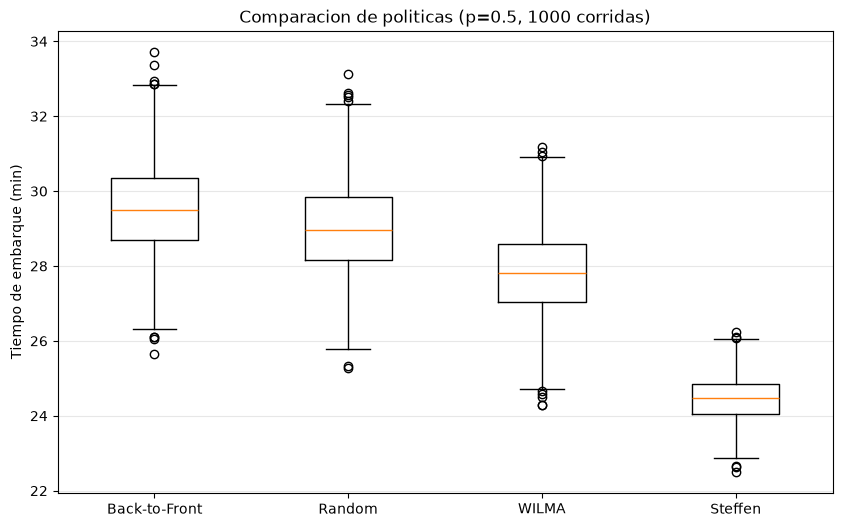

In [ ]:
plt.figure(figsize=(10, 6))
plt.boxplot([resultados[n]["tiempos"] / 60 for n in politicas],
            tick_labels=list(politicas.keys()))
plt.ylabel("Tiempo de embarque (min)")
plt.title("Comparacion de politicas (p=0.5, 1000 corridas)")
plt.grid(axis="y", alpha=0.3)
plt.show()


#### Analisis de sensibilidad a `p`

El enunciado pide ver que pasa con `p=1` (todos con carry-on) y `p=0` (nadie). Corremos las 4 politicas para `p` en {0, 0.5, 1}.


In [ ]:
ps = [0.0, 0.5, 1.0]
sensibilidad = {}

print(f"{'Politica':<15}" + "".join(f"p={p:<8}" for p in ps) + "(media min)")
for nombre, fn in politicas.items():
    fila = []
    for p in ps:
        r = correr_montecarlo(fn, p_carryon=p)
        sensibilidad[(nombre, p)] = r
        fila.append(f"{r['media']/60:<10.2f}")
    print(f"{nombre:<15}" + "".join(fila))


Politica       p=0.0     p=0.5     p=1.0     (media min)
Back-to-Front  18.28     29.58     36.97     


In [ ]:
# Barras agrupadas: 3 valores discretos de p por politica.
# Usamos barras (no lineas) porque solo medimos p en {0, 0.5, 1}:
# unir 3 puntos con lineas sugeriria una tendencia continua que no simulamos.
# Cada barra lleva su error de estimacion (IC 95%) como linea vertical (yerr).
nombres = list(politicas)
x = np.arange(len(nombres))       # una posicion por politica
ancho = 0.25                      # ancho de cada barra

plt.figure(figsize=(10, 6))
for i, pcarry in enumerate(ps):
    alturas, errores = [], []
    for nombre in nombres:
        tiempos = sensibilidad[(nombre, pcarry)]["tiempos"]
        media = tiempos.mean() / 60                                  # min
        ic95 = 1.96 * tiempos.std(ddof=1) / np.sqrt(len(tiempos)) / 60  # IC 95% en min
        alturas.append(media)
        errores.append(ic95)
    # corremos cada grupo de barras para que no se pisen
    plt.bar(x + (i - 1) * ancho, alturas, width=ancho, label=f"p = {pcarry}",
            yerr=errores, capsize=4)

plt.xticks(x, nombres)
plt.xlabel("Politica")
plt.ylabel("Tiempo medio de embarque (min)")
plt.title("Impacto del carry-on en el tiempo de embarque por politica")
plt.legend(title="Prob. carry-on")
plt.grid(axis="y", alpha=0.3)
plt.show()


NameError: name 'politicas' is not defined

#### Validacion contra datos reales (Steffen, 2011)

Tiempos medidos con pasajeros reales por Steffen & Hotchkiss (2011). No esperamos un match exacto (avion distinto, sin asiento del medio), pero si deberia mantenerse el **orden relativo**: Steffen < WILMA < Random < Back-to-Front.


In [ ]:
reales_min = {
    "Back-to-Front": 6 + 11/60,
    "Random":        4 + 44/60,
    "WILMA":         4 + 13/60,
    "Steffen":       3 + 36/60,
}

print(f"{'Politica':<15}{'Sim':>8}{'Real':>8}{'Dif%':>8}")
for nombre in politicas:
    sim = resultados[nombre]["media"] / 60
    real = reales_min[nombre]
    print(f"{nombre:<15}{sim:>8.2f}{real:>8.2f}{100*(sim-real)/real:>7.0f}%")


Politica            Sim    Real    Dif%
Back-to-Front     29.58    6.18    378%
Random            29.14    4.73    516%
WILMA             27.85    4.22    561%
Steffen           24.51    3.60    581%


#### Analisis de negocio: costo de la demora

Una demora en el embarque retrasa la salida y cuesta plata a la aerolínea (tripulación, ocupación de puerta, conexiones perdidas, combustible). Tomamos un costo por minuto de referencia y valuamos el ahorro de cada politica frente a la mas lenta (Back-to-Front).

`costo_min` es un valor de referencia: (convendría reemplazar por una fuente citada) (p. ej. estimaciones de costo directo de demora de la industria, del orden de USD 70-100/min).


In [ ]:
costo_min = 90  # USD por minuto de demora

base = resultados["Back-to-Front"]["media"]
print(f"{'Politica':<15}{'Ahorro min':>12}{'USD/vuelo':>12}")
for nombre, r in resultados.items():
    ahorro_min = (base - r["media"]) / 60
    print(f"{nombre:<15}{ahorro_min:>12.2f}{ahorro_min*costo_min:>12.0f}")


Politica         Ahorro min   USD/vuelo
Back-to-Front          0.00           0
Random                 0.44          40
WILMA                  1.72         155
Steffen                5.07         456


### Visualización: animación del embarque

Animamos el embarque con dos herramientas nuevas: `matplotlib.animation.FuncAnimation` y `matplotlib.colors.to_rgba`.

In [ ]:
import matplotlib.animation as animation
from matplotlib.colors import to_rgba
from matplotlib.patches import Patch
from matplotlib.path import Path

# Un color por estado, mas un color aparte para las posiciones vacias.
COLOR_VACIO = "#f0f0f0"

COLORES_ESTADO = {
    ESTADO_CAMINANDO: "#4C72B0",          # caminando por el pasillo
    ESTADO_BLOQUEADO: "#DD8452",          # esperando que se libere el pasillo
    ESTADO_GUARDANDO_CARRYON: "#8172B2",  # guardando el carry-on
    ESTADO_SENTANDOSE: "#CCB974",         # sentandose (incluye el caso de dejar pasar)
    ESTADO_SENTADO: "#55A868",            # ya sentado
}


def _figura_persona():
    """
    Arma la silueta de una personita parada, para usarla como 'marker' en
    un scatter (en vez de los cuadrados de antes). Un Path es basicamente
    una receta de dibujo: una lista de puntos mas instrucciones de como
    conectarlos ("movete aca", "traza una linea hasta aca", "cerra la
    figura"). Armamos la cabeza (un circulo, Path.unit_circle() ya viene
    definido en matplotlib) y el cuerpo (un trapecio, mas ancho arriba
    en los hombros que abajo en la cintura), y los combinamos en un
    unico Path. El guion bajo adelante del nombre (_figura_persona) es
    solo una convencion: avisa que es una funcion auxiliar, no algo que
    vayamos a llamar desde afuera de esta celda.
    """
    cabeza = Path.unit_circle()
    vertices_cabeza = cabeza.vertices * 0.38 + np.array([0, 0.55])
    codigos_cabeza = cabeza.codes

    vertices_cuerpo = np.array([
        [-0.40, 0.25],
        [0.40, 0.25],
        [0.25, -0.60],
        [-0.25, -0.60],
        [-0.40, 0.25],
    ])
    codigos_cuerpo = [Path.MOVETO, Path.LINETO, Path.LINETO, Path.LINETO, Path.CLOSEPOLY]

    vertices = np.concatenate([vertices_cabeza, vertices_cuerpo])
    codigos = np.concatenate([codigos_cabeza, codigos_cuerpo])

    return Path(vertices, codigos)


MARCADOR_PERSONA = _figura_persona()


def _fondo_vacio(filas, columnas):
    imagen = np.zeros((filas, columnas, 4))
    imagen[:, :] = to_rgba(COLOR_VACIO)
    return imagen


def posiciones_y_colores(avion, pasajeros_por_id, indice_historial):
    """
    Para un segundo puntual de la simulacion, arma 3 listas paralelas
    (la posicion i de las 3 listas describe al mismo pasajero): en que
    columna esta, en que fila, y de que color pintarlo segun su estado
    en ese momento. Las celdas vacias no se incluyen (no hay nadie que dibujar ahi).
    """
    matriz_ids = avion.historial[indice_historial]["matriz"]
    filas, columnas = matriz_ids.shape

    xs, ys, colores = [], [], []

    for fila in range(filas):
        for columna in range(columnas):
            id_pasajero = matriz_ids[fila, columna]
            if id_pasajero == 0:
                continue

            pasajero = pasajeros_por_id[id_pasajero]
            estado_en_ese_momento = pasajero.estado[indice_historial]

            xs.append(columna)
            ys.append(fila)
            colores.append(COLORES_ESTADO[estado_en_ese_momento])

    return xs, ys, colores


def animar_embarque(avion, paso=5, intervalo_ms=60, titulo="Embarque"):
    """
    Devuelve una animacion (FuncAnimation) del embarque ya simulado en `avion`.

    `paso`: cada cuantos segundos de la simulacion se muestra un cuadro.
    Un embarque completo dura miles de segundos, animar uno por uno seria
    demasiado lento y pesado, por eso saltamos de a `paso` segundos.
    """
    pasajeros_por_id = {pasajero.id: pasajero for pasajero in avion.pasajeros}

    indices = list(range(0, len(avion.historial), paso))
    ultimo_indice = len(avion.historial) - 1
    if indices[-1] != ultimo_indice:
        indices.append(ultimo_indice)  # nos aseguramos de terminar mostrando el avion lleno

    filas, columnas = avion.historial[0]["matriz"].shape

    fig, ax = plt.subplots(figsize=(4.8, 9))

    # El fondo (las celdas vacias) se dibuja una sola vez, antes de animar nada.
    ax.imshow(_fondo_vacio(filas, columnas), aspect="auto")

    xs0, ys0, colores0 = posiciones_y_colores(avion, pasajeros_por_id, indices[0])
    dispersion = ax.scatter(
        xs0, ys0, c=colores0 if colores0 else None,
        marker=MARCADOR_PERSONA, s=260, linewidths=0,
    )

    ax.set_xlim(-0.5, columnas - 0.5)
    ax.set_ylim(filas - 0.5, -0.5)  # invertido: la fila 0 (puerta) queda arriba
    ax.set_xticks(range(columnas))
    ax.set_xticklabels(["Ventana\nizq.", "Pasillo\nizq.", "Pasillo\ncentral", "Pasillo\nder.", "Ventana\nder."], fontsize=7)
    ax.set_yticks([0, filas - 1])
    ax.set_yticklabels([f"Fila 1\n(puerta)", f"Fila {filas}\n(fondo)"])
    ax.set_title(f"{titulo} \u2014 0 seg")

    leyenda = [
        Patch(facecolor=COLORES_ESTADO[ESTADO_CAMINANDO], label="Caminando"),
        Patch(facecolor=COLORES_ESTADO[ESTADO_BLOQUEADO], label="Bloqueado / esperando"),
        Patch(facecolor=COLORES_ESTADO[ESTADO_GUARDANDO_CARRYON], label="Guardando carry-on"),
        Patch(facecolor=COLORES_ESTADO[ESTADO_SENTANDOSE], label="Sentandose"),
        Patch(facecolor=COLORES_ESTADO[ESTADO_SENTADO], label="Sentado"),
        Patch(facecolor=COLOR_VACIO, label="Vacio"),
    ]
    ax.legend(handles=leyenda, loc="upper center", bbox_to_anchor=(0.5, -0.08),
              ncol=2, fontsize=7, frameon=False)
    fig.tight_layout()

    def actualizar(indice_historial):
        # FuncAnimation llama a esto una vez por cuadro.
        xs, ys, colores = posiciones_y_colores(avion, pasajeros_por_id, indice_historial)
        offsets = np.column_stack([xs, ys]) if xs else np.empty((0, 2))
        dispersion.set_offsets(offsets)
        if colores:
            dispersion.set_facecolor(colores)
        segundo = avion.historial[indice_historial]["segundo"]
        ax.set_title(f"{titulo} \u2014 {segundo} seg ({segundo / 60:.1f} min)")
        return [dispersion]

    anim = animation.FuncAnimation(fig, actualizar, frames=indices, interval=intervalo_ms)
    plt.close(fig)  # evita que ademas del reproductor aparezca una imagen suelta
    return anim

In [ ]:
avion_random = simular_embarque(orden_random, p_carryon=0.5)
print(f"Este embarque (Random) tardo {avion_random.reloj} segundos ({avion_random.reloj/60:.2f} minutos)")

anim = animar_embarque(avion_random, paso=5, titulo="Embarque - Random")

# Guardamos la animacion como GIF (para usar en las slides). Necesita
# la libreria Pillow instalada (si da error, correr: pip install pillow).
anim.save("embarque_random.gif", writer="pillow", fps=15)

print("Listo: embarque_random.gif")

Este embarque (Random) tardo 1687 segundos (28.12 minutos)
Listo: embarque_random.gif


### Herramienta interactiva: elegir método, $p$ y velocidad

Acá usamos una libreria nueva, `ipywidgets` (viene con Jupyter/Anaconda; si no está instalada, correr `pip install ipywidgets` en una celda). Sirve para poner controles (un desplegable, sliders, un boton) directamente en el notebook, sin tener que tocar codigo cada vez que querés probar otro método, otro p, u otra velocidad.

La 'velocidad' acá es la misma que ya teníamos como `paso` en `animar_embarque`: cuántos segundos de simulación avanza cada cuadro de la animación (no la velocidad de caminata de los pasajeros, esa la fija el enunciado y no la tocamos). O sea, es un control de "qué tan rápido se ve la animación", no de la física de la simulación.

También agregamos un boton "Descargar GIF" al lado del de simular. Para que sepa que animacion guardar sin tener que volver a simular, la guardamos en `ultima_animacion`, un diccionario creado afuera de las dos funciones.

In [ ]:
import ipywidgets as widgets
from IPython.display import display, HTML, clear_output

# Cada opcion del desplegable es un par (texto que se ve, funcion real).
metodo_selector = widgets.Dropdown(
    options=[
        ("Random", orden_random),
        ("Back-to-Front", orden_back_to_front),
        ("WILMA", orden_wilma),
        ("Steffen", orden_steffen),
    ],
    value=orden_random,
    description="Metodo:",
)

p_selector = widgets.FloatSlider(
    value=0.5, min=0.0, max=1.0, step=0.05,
    description="p (carry-on):", readout_format=".2f",
)

velocidad_selector = widgets.IntSlider(
    value=5, min=1, max=20, step=1,
    description="Velocidad:",
)

boton_simular = widgets.Button(description="Simular y animar", button_style="primary")
boton_descargar = widgets.Button(description="Descargar GIF", button_style="success")
salida = widgets.Output()

# Guardamos aca la ultima animacion generada, para que el boton de
# descargar sepa que archivo armar sin tener que simular de nuevo.
# Ver la celda de markdown de arriba para el por que del diccionario.
ultima_animacion = {"anim": None, "etiqueta": None}


def al_hacer_clic_simular(boton):
    """Se ejecuta cada vez que se aprieta boton_simular."""
    with salida:
        clear_output(wait=True)  # borra el resultado anterior antes de mostrar el nuevo

        politica_elegida = metodo_selector.value
        p_elegido = p_selector.value
        paso_elegido = velocidad_selector.value

        print(f"Simulando embarque: {metodo_selector.label}, p={p_elegido:.2f}...")
        avion = simular_embarque(politica_elegida, p_carryon=p_elegido)
        print(f"Termino en {avion.reloj} segundos ({avion.reloj / 60:.2f} minutos). Generando animacion...")

        anim = animar_embarque(avion, paso=paso_elegido, titulo=f"Embarque - {metodo_selector.label}")

        # Guardamos esta animacion como "la ultima", para el boton de descargar.
        ultima_animacion["anim"] = anim
        ultima_animacion["etiqueta"] = f"{metodo_selector.label}_p{p_elegido:.2f}".lower().replace("-", "_")

        display(HTML(anim.to_jshtml()))
        print("Si te gusta como quedo, apreta 'Descargar GIF' para guardarla como archivo.")


def al_hacer_clic_descargar(boton):
    """Se ejecuta cada vez que se aprieta boton_descargar."""
    with salida:
        if ultima_animacion["anim"] is None:
            print("Primero apreta 'Simular y animar' para generar una animacion.")
            return

        nombre_archivo = f"embarque_{ultima_animacion['etiqueta']}.gif"
        print(f"Guardando {nombre_archivo}...")
        ultima_animacion["anim"].save(nombre_archivo, writer="pillow", fps=15)
        print(f"Listo: {nombre_archivo} (queda guardado en la misma carpeta del notebook).")


boton_simular.on_click(al_hacer_clic_simular)
boton_descargar.on_click(al_hacer_clic_descargar)

display(widgets.VBox([
    metodo_selector,
    p_selector,
    velocidad_selector,
    widgets.HBox([boton_simular, boton_descargar]),
    salida,
]))

# Creador de csv

In [ ]:
import pandas as pd

avion_random = simular_embarque(orden_random, p_carryon=0.5)

print(f"Simulación lista: {avion_random.reloj} segundos")
avion = avion_random

# Traducción de los estados numéricos a nombres.
NOMBRES_ESTADO = {
    ESTADO_CAMINANDO: "CAMINANDO",
    ESTADO_SENTADO: "SENTADO",
    ESTADO_BLOQUEADO: "BLOQUEADO",
    ESTADO_GUARDANDO_CARRYON: "GUARDANDO_CARRYON",
    ESTADO_SENTANDOSE: "SENTANDOSE",
}

datos = []

# Recorremos cada pasajero
for pasajero in avion.pasajeros:

    # Recorremos cada segundo de la simulación
    for segundo in range(len(pasajero.ubicacion)):

        ubicacion = pasajero.ubicacion[segundo]
        estado = pasajero.estado[segundo]

        # Si el pasajero todavía no entró al avión,
        # representamos su posición como -1.
        if ubicacion == -1:
            fila = -1
            columna = -1
        else:
            fila, columna = ubicacion

            # Convertimos la fila interna de numpy (0-24)
            # a la fila real del avión (1-25).
            fila += 1

        datos.append({
            "segundo": segundo,
            "pasajero_id": pasajero.id,
            "asiento_fila": pasajero.asiento[0],
            "asiento_lado": pasajero.asiento[1],
            "carryon": pasajero.carryon,
            "fila": fila,
            "columna": columna,
            "estado": NOMBRES_ESTADO[estado],
        })

datos = []

# Primero recorremos cada segundo
for segundo in range(len(avion.pasajeros[0].ubicacion)):

    # Después recorremos todos los pasajeros
    for pasajero in avion.pasajeros:

        ubicacion = pasajero.ubicacion[segundo]
        estado = pasajero.estado[segundo]

        if ubicacion == -1:
            fila = -1
            columna = -1
        else:
            fila, columna = ubicacion
            fila += 1

        datos.append({
            "segundo": segundo,
            "pasajero_id": pasajero.id,
            "asiento_fila": pasajero.asiento[0],
            "asiento_lado": pasajero.asiento[1],
            "carryon": pasajero.carryon,
            "fila": fila,
            "columna": columna,
            "estado": NOMBRES_ESTADO[estado],
        })

df_simulacion = pd.DataFrame(datos)

df_simulacion.to_csv("simulacion_random_p05.csv", index=False)

print(f"CSV creado: simulacion_random_p05.csv")
print(f"Filas exportadas: {len(df_simulacion)}")
print(f"Duración de la simulación: {avion.reloj} segundos")

Simulación lista: 1690 segundos
CSV creado: simulacion_random_p05.csv
Filas exportadas: 169100
Duración de la simulación: 1690 segundos
